In [1]:
import rootutils
from pathlib import Path
PROJECT_ROOT = rootutils.setup_root(
    search_from=Path.cwd(), dotenv=True, pythonpath=True, cwd=False)

# import numpy as np
# from numpy.typing import NDArray
# from typing import Tuple

from src.zupt_ins.zupt_ins import smoothed_zupt_aided_ins
from src.zupt_ins.data_classes import InertialData, Trajectory
from src.zupt_ins.initialization import INSConfig

### Load data

In [ ]:
inertial = InertialData.from_csv_int(PROJECT_ROOT / "data/angermann_high_precision", 15)
gt_traj = Trajectory.from_csv_int(PROJECT_ROOT / "data/angermann_high_precision", 15)
simdata = INSConfig(
    segmentation_thrsld=0.03 # segments the steps
)

### Process data with Smoothed ZUPT aided INS

In [3]:
zupt, ins_traj = smoothed_zupt_aided_ins(inertial, simdata)

### Plot

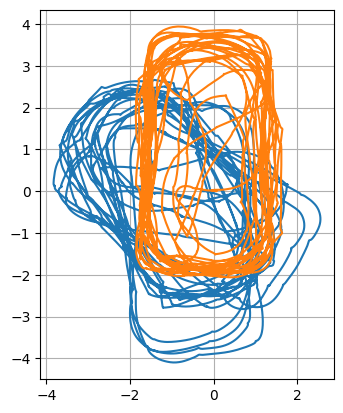

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(ins_traj.pos[0,:-1], ins_traj.pos[1,:-1])
ax.plot(gt_traj.pos[0,:-1], gt_traj.pos[1,:-1])
ax.set_aspect('equal')
ax.grid(visible=True)

### Test using Ground thruth timestamps aligned to IMU measurements

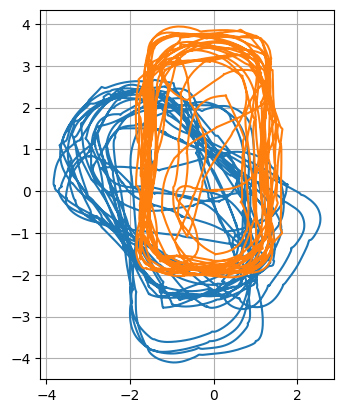

In [5]:
import src.zupt_ins.data_preprocessing as preprocessing

gt_traj_aligned = preprocessing.temporal_alignment(ins_traj.t, gt_traj)
fig, ax = plt.subplots()
ax.plot(ins_traj.pos[0, :-1], ins_traj.pos[1, :-1])
ax.plot(gt_traj_aligned.pos[0, :-1], gt_traj_aligned.pos[1, :-1])
ax.set_aspect('equal')
ax.grid(visible=True)

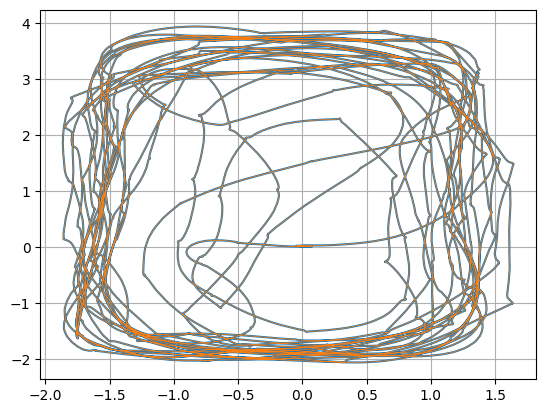

In [6]:
## Compare Groundtruths
fig, ax = plt.subplots()
ax.plot(gt_traj.pos[0,:-1], gt_traj.pos[1,:-1])
ax.plot(gt_traj_aligned.pos[0,:-1], gt_traj_aligned.pos[1,:-1], linewidth = 0.5)
ax.grid(visible=True)
plt.show()